In [ ]:
import numpy as np
import pandas as pd
# pd.set_option('display.max_columns', 30)
# pd.set_option('display.max_rows', None)
import matplotlib.pyplot as plt
import glob, json
import sys

%load_ext autoreload
%autoreload 2

from cmlreaders import get_data_index, CMLReader

# Heartbeat helpers — co-located in the same heartbeat/ folder as this
# notebook, so no sys.path insert needed.
from fix_heartbeats_sys4 import (
    ms_to_datetime,
    get_heart,
    correct_event_times,
    prepare_merged_heartbeats,
    fit_correction,
    get_heartbeat_correction,
    check_heartbeat_onsets,
)



In [3]:
data = get_data_index(kind='r1').query('system_version == 4 and experiment == "RepFR1"')

In [4]:
data

,Recognition,all_events,contacts,experiment,import_type,localization,math_events,montage,original_experiment,original_session,pairs,ps4_events,session,subject,subject_alias,system_version,task_events
1193,NaN,protocols/r1/subjects/R1204T/experiments/RepFR...,protocols/r1/subjects/R1204T/localizations/1/m...,RepFR1,build,1,NaN,1,NaN,NaN,protocols/r1/subjects/R1204T/localizations/1/m...,NaN,0,R1204T,R1204T_1,4.0,protocols/r1/subjects/R1204T/experiments/RepFR...
1194,NaN,NaN,protocols/r1/subjects/R1204T/localizations/1/m...,RepFR1,build,1,NaN,1,NaN,1,protocols/r1/subjects/R1204T/localizations/1/m...,NaN,1,R1204T,R1204T_1,4.0,protocols/r1/subjects/R1204T/experiments/RepFR...
1195,NaN,protocols/r1/subjects/R1204T/experiments/RepFR...,protocols/r1/subjects/R1204T/localizations/1/m...,RepFR1,build,1,NaN,1,NaN,NaN,protocols/r1/subjects/R1204T/localizations/1/m...,NaN,2,R1204T,R1204T_1,4.0,protocols/r1/subjects/R1204T/experiments/RepFR...
2533,NaN,protocols/r1/subjects/R1556J/experiments/RepFR...,NaN,RepFR1,build,1,NaN,1,NaN,NaN,NaN,NaN,0,R1556J,R1556J_1,4.0,protocols/r1/subjects/R1556J/experiments/RepFR...
2534,NaN,protocols/r1/subjects/R1556J/experiments/RepFR...,NaN,RepFR1,build,1,NaN,1,NaN,NaN,NaN,NaN,1,R1556J,R1556J_1,4.0,protocols/r1/subjects/R1556J/experiments/RepFR...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3099,NaN,protocols/r1/subjects/R1681J/experiments/RepFR...,protocols/r1/subjects/R1681J/localizations/0/m...,RepFR1,build,0,NaN,0,NaN,NaN,protocols/r1/subjects/R1681J/localizations/0/m...,NaN,3,R1681J,R1681J,4.0,protocols/r1/subjects/R1681J/experiments/RepFR...
3100,NaN,protocols/r1/subjects/R1681J/experiments/RepFR...,protocols/r1/subjects/R1681J/localizations/0/m...,RepFR1,build,0,NaN,0,NaN,NaN,protocols/r1/subjects/R1681J/localizations/0/m...,NaN,4,R1681J,R1681J,4.0,protocols/r1/subjects/R1681J/experiments/RepFR...
3145,NaN,protocols/r1/subjects/R1690E/experiments/RepFR...,protocols/r1/subjects/R1690E/localizations/0/m...,RepFR1,build,0,NaN,0,NaN,NaN,protocols/r1/subjects/R1690E/localizations/0/m...,NaN,0,R1690E,R1690E,4.0,protocols/r1/subjects/R1690E/experiments/RepFR...
3146,NaN,protocols/r1/subjects/R1690E/experiments/RepFR...,protocols/r1/subjects/R1690E/localizations/0/m...,RepFR1,build,0,NaN,0,NaN,NaN,protocols/r1/subjects/R1690E/localizations/0/m...,NaN,1,R1690E,R1690E,4.0,protocols/r1/subjects/R1690E/experiments/RepFR...


In [17]:
r = CMLReader(subject='R1621E', experiment='RepFR1', session=1,
                      localization=0, montage=0)

In [18]:
eeg = r.load_eeg()

In [19]:
eeg.samplerate


1000

In [2]:
# Collect raw heartbeats for every System-4 session AND prepare a
# merged_df per session ready for fit_correction(). Sessions where the
# task-laptop heartbeats are missing get NO merged_df - they are simply
# skipped (no correction is applied downstream).

# Restrict which experiments to load. Comment in/out as needed.
exps = ['RepFR1'
    # 'RepFR1', 'RepFR2',
    # 'EFRCourierOpenLoop', 'EFRCourierReadOnly',  # several early sessions with errors
    # 'catFR1', 'ICatFR1', 'IFR1',                 # HEARTBEATs not recorded on task side
    # 'IFR6', 'ICatFR6', 'CPS',
]

data = get_data_index(kind='r1').query('system_version == 4 and experiment in @exps')
drop_network_test = True

heartbeats = list()
prepared_by_sess = {}    # (sub, exp, sess, orig_sess) -> {merged_df, prep_err, n_task, n_host}

for idx, row in data.iterrows():
    print('-' * 96)
    print(f'{row.subject}, {row.experiment}, session {row.session}')
    sess = None
    hb_task = None
    hb_host = None
    try:
        r = CMLReader(subject=row.subject, experiment=row.experiment, session=row.session,
                      localization=row.localization, montage=row.montage)
        evs = r.load('events')
        sess = row.original_session if not row.isna().original_session else row.session

        try:
            hb_task = get_heart(row.subject_alias, row.experiment, sess,
                                drop_network_test=drop_network_test,
                                load_host_pc=False, verbose=True)
            hb_task['original_session'] = hb_task.session
            hb_task.loc[:, ['session']] = row.session
            heartbeats.append(hb_task)
        except Exception as e:
            print(f'  task_laptop get_heart failed: {type(e).__name__}: {e}')

        try:
            hb_host = get_heart(row.subject_alias, row.experiment, sess,
                                drop_network_test=drop_network_test,
                                load_host_pc=True, verbose=True)
            hb_host['original_session'] = hb_host.session
            hb_host.loc[:, ['session']] = row.session
            heartbeats.append(hb_host)
        except Exception as e:
            print(f'  host_pc get_heart failed: {type(e).__name__}: {e}')
    except Exception as e:
        print(f'Error on {row.subject_alias}, {row.experiment}, session {sess}:')
        print(e)
        continue

    # Build the merged_df only if BOTH task and host loaded. Skip otherwise.
    merged_df = None
    prep_err = None
    if hb_task is not None and hb_host is not None:
        try:
            merged_df = prepare_merged_heartbeats(pd.concat([hb_task, hb_host], ignore_index=True))
        except Exception as e:
            prep_err = f'prepare failed: {type(e).__name__}: {e}'
    elif hb_task is None and hb_host is not None:
        prep_err = 'task-laptop heartbeats missing - skipping correction'
    elif hb_host is None:
        prep_err = 'host heartbeats missing - skipping correction'
    else:
        prep_err = 'no heartbeats loaded'

    prepared_by_sess[(row.subject, row.experiment, row.session, sess)] = {
        'merged_df': merged_df,
        'prep_err': prep_err,
        'n_task': 0 if hb_task is None else len(hb_task),
        'n_host': 0 if hb_host is None else len(hb_host),
    }

heartbeats = pd.concat(heartbeats, ignore_index=True) if heartbeats else pd.DataFrame()

n_with_merged = sum(1 for v in prepared_by_sess.values() if v['merged_df'] is not None)
print(f'\nsessions with usable merged_df: {n_with_merged} / {len(prepared_by_sess)}')
heartbeats.head(3)



------------------------------------------------------------------------------------------------
R1204T, RepFR1, session 0
['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_0/session.jsonl']
HEARTBEAT statistics for task_laptop
Minimum latency: 0.5 ms, Maximum latency: 336.92 ms
Tenth percentile latency: 0.75 ms. Ninetieth percentile latency: 1.2 ms
Latencies greater than 100 ms: 0.02379%

['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_0/elemem/R1204T_1_2021-09-30_12-31-27/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.03 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------------------------------------------------------------------------------
R1204T, RepFR1, session 1
['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_1/session.jsonl']


/home1/zrentala/bids-convert/intracranial/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


HEARTBEAT statistics for task_laptop
Minimum latency: 0.56 ms, Maximum latency: 56.04 ms
Tenth percentile latency: 0.78 ms. Ninetieth percentile latency: 1.22 ms
Latencies greater than 100 ms: 0.0%

['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_1/elemem/R1204T_1_2021-10-04_13-53-20/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.02 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------------------------------------------------------------------------------
R1204T, RepFR1, session 2
['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_2/session.jsonl']


/home1/zrentala/bids-convert/intracranial/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


HEARTBEAT statistics for task_laptop
Minimum latency: 0.61 ms, Maximum latency: 55.54 ms
Tenth percentile latency: 0.83 ms. Ninetieth percentile latency: 1.47 ms
Latencies greater than 100 ms: 0.0%

['/data10/RAM/subjects/R1204T_1/behavioral/RepFR1/session_2/elemem/R1204T_1_2021-10-05_11-01-06/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.01 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------------------------------------------------------------------------------
R1556J, RepFR1, session 0
['/data10/RAM/subjects/R1556J_1/behavioral/RepFR1/session_0/session.jsonl']


...

/home1/zrentala/bids-convert/intracranial/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)
/home1/zrentala/bids-convert/intracranial/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)


HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.0 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------------------------------------------------------------------------------
R1690E, RepFR1, session 0
['/data10/RAM/subjects/R1690E/behavioral/RepFR1/session_0/session.jsonl']
HEARTBEAT statistics for task_laptop
Minimum latency: 0.74 ms, Maximum latency: 186.17 ms
Tenth percentile latency: 1.29 ms. Ninetieth percentile latency: 4.7 ms
Latencies greater than 100 ms: 1.734%

['/data10/RAM/subjects/R1690E/behavioral/RepFR1/session_0/elemem/R1690E_2023-07-18_13-40-20/event.log']
HEARTBEAT statistics for host_pc
Minimum latency: 0.0 ms, Maximum latency: 1.0 ms
Tenth percentile latency: 0.0 ms. Ninetieth percentile latency: 0.0 ms
Latencies greater than 100 ms: 0.0%

------------------------------------------------------------------------------------------------
R1690E, RepFR1, sessi

/home1/zrentala/bids-convert/intracranial/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)
/home1/zrentala/bids-convert/intracranial/fix_heartbeats_sys4.py:126: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  heart_beat.drop('message', axis=1, inplace=True)



sessions with usable merged_df: 95 / 101


,subject,experiment,session,original_session,hardware_system,count,time,time_HEARTBEAT_OK,latency,id
0,R1204T_1,RepFR1,0,0,task_laptop,21.0,1.633023e+12,1.633023e+12,0.920166,116.0
1,R1204T_1,RepFR1,0,0,task_laptop,22.0,1.633023e+12,1.633023e+12,1.180176,120.0
2,R1204T_1,RepFR1,0,0,task_laptop,23.0,1.633023e+12,1.633023e+12,1.340088,124.0


In [ ]:
# get all sessions with heartbeat issues and saves them in csv
# (separate task from the main heartbeats/correction flow above — uncomment to re-run)
data_all = get_data_index(kind = 'r1').query('system_version == 4')
drop_network_test = True
import glob, json as _json, re, datetime, os as _os

BROKEN_EPL_START_MS = 1646685973000  # 0b72b0b 'Added FR5 experiment for Elemem' 2022-03-07
BROKEN_EPL_END_MS   = 1733175470000  # ff9f602 'Fix heartbeats'                 2024-12-02

def get_session_time_ms(subject, exp, sess):
    """Approximate session start time in unix-ms.

    Tries (in order): the `time` field on the first valid record of
    session.jsonl, then a YYYY-MM-DD_HH-MM-SS substring on an elemem subdir,
    then None.
    """
    jsonl = f'/data10/RAM/subjects/{subject}/behavioral/{exp}/session_{sess}/session.jsonl'
    if _os.path.exists(jsonl):
        with open(jsonl) as f:
            for line in f:
                try:
                    rec = _json.loads(line)
                except Exception:
                    continue
                if isinstance(rec, dict) and 'time' in rec:
                    try:
                        return float(rec['time'])
                    except Exception:
                        pass
    elemem_dirs = glob.glob(
        f'/data10/RAM/subjects/{subject}/behavioral/{exp}/session_{sess}/elemem/*'
    )
    for d in elemem_dirs:
        m = re.search(r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})', _os.path.basename(d))
        if m:
            try:
                dt = datetime.datetime.strptime(m.group(1), '%Y-%m-%d_%H-%M-%S')
                return dt.timestamp() * 1000.0
            except Exception:
                pass
    return None

heartbeats = []
missing_hardware_sessions = []  # populated below: sessions where task or host get_heart() failed
broken_epl_sessions = []        # populated below: sessions recorded inside the broken UnityEPL-FR window
high_latency_corrections = []   # populated below: sessions with any heartbeat latency > 1 ms
session_max_latency = {}        # (subject, experiment, session) -> max latency seen across hardware
for idx, row in data_all.iterrows():
    print('------------------------------------------------------------------------------------')
    print(f'{row.subject}, {row.experiment}, session {row.session}')
    sess = None
    try:
        r = CMLReader(subject=row.subject, experiment=row.experiment, session=row.session,
                        localization=row.localization, montage=row.montage)
        evs = r.load('events')
        sess = row.original_session if not row.isna().original_session else row.session
    except Exception as e:
        print(f'Error setting up CMLReader for {row.subject_alias}, {row.experiment}, session {row.session}: {e}')
        continue

    sess_time_ms = get_session_time_ms(row.subject_alias, row.experiment, sess)
    if sess_time_ms is not None and BROKEN_EPL_START_MS <= sess_time_ms <= BROKEN_EPL_END_MS:
        broken_epl_sessions.append({
            'subject': row.subject,
            'experiment': row.experiment,
            'session': row.session,
            'original_session': sess,
            'sess_time_ms': sess_time_ms,
        })

    task_err = None
    host_err = None

    # task laptop heartbeats from session.jsonl
    task_max_lat = None
    try:
        tmp = get_heart(row.subject_alias, row.experiment, sess,
                        drop_network_test=drop_network_test,
                        load_host_pc=False, verbose=True)
        tmp['original_session'] = tmp.session
        tmp.loc[:, ['session']] = row.session
        heartbeats.append(tmp)
        if 'latency' in tmp.columns and tmp['latency'].notna().any():
            task_max_lat = float(tmp['latency'].max())
    except Exception as e:
        task_err = f'{type(e).__name__}: {e}'
        print(f'  task_laptop get_heart failed: {task_err}')

    # host PC heartbeats from event.log
    host_max_lat = None
    try:
        tmp = get_heart(row.subject_alias, row.experiment, sess,
                        drop_network_test=drop_network_test,
                        load_host_pc=True, verbose=True)
        tmp['original_session'] = tmp.session
        tmp.loc[:, ['session']] = row.session
        heartbeats.append(tmp)
        if 'latency' in tmp.columns and tmp['latency'].notna().any():
            host_max_lat = float(tmp['latency'].max())
    except Exception as e:
        host_err = f'{type(e).__name__}: {e}'
        print(f'  host_pc get_heart failed: {host_err}')

    candidate_lats = [v for v in (task_max_lat, host_max_lat) if v is not None]
    max_lat = max(candidate_lats) if candidate_lats else None
    if max_lat is not None and max_lat > 1:
        high_latency_corrections.append({
            'subject': row.subject,
            'experiment': row.experiment,
            'session': row.session,
            'original_session': sess,
            'max_latency_ms': max_lat,
            'task_max_latency_ms': task_max_lat,
            'host_max_latency_ms': host_max_lat,
        })

    print(task_err)
    print(host_err)
    if task_err or host_err:
        missing_hardware_sessions.append({
            'subject': row.subject,
            'experiment': row.experiment,
            'session': row.session,
            'original_session': sess,
            'missing_task_laptop': task_err is not None,
            'missing_host_pc': host_err is not None,
            'task_error': task_err,
            'host_error': host_err,
        })

heartbeats = pd.concat(heartbeats, ignore_index=True) if heartbeats else pd.DataFrame()

# Save sessions with any heartbeat latency > 1 ms
import os
os.makedirs('results', exist_ok=True)
high_latency_df = pd.DataFrame(high_latency_corrections)
high_latency_df.to_csv('results/sess_latency_over_1ms.csv', index=False)
print(f"\nSaved {len(high_latency_df)} sessions with latency > 1 ms to results/sess_latency_over_1ms.csv")

broken_epl_df = pd.DataFrame(broken_epl_sessions)
broken_epl_df.to_csv('results/sess_within_broken_epl.csv', index=False)
print(f"Saved {len(broken_epl_df)} sessions in the broken UnityEPL-FR window to results/sess_within_broken_epl.csv")

missing_hw_df = pd.DataFrame(missing_hardware_sessions)
missing_hw_df.to_csv('results/sess_missing_heartbeats.csv', index=False)
print(f"Saved {len(missing_hw_df)} sessions missing task_laptop or host_pc heartbeats to results/sess_missing_heartbeats.csv")

------------------------------------------------------------------------------------------------
R1204T RepFR1 session 0 original session 0
Number of heartbeats: 2000
RANSAC inliers: 2000 / 2000 (100.0%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999999579
RMS residual (all):     0.331682 ms
RMS residual (inliers): 0.331682 ms
Slope: 0.999962
Offset: 6.15345e+07 ms
Slope of linear fit too far from 1: 0.9999623116142169
Proportion of positive residuals after adjustment for network delay: 0.0775
------------------------------------------------------------------------------------------------
R1204T RepFR1 session 1 original session 1
Number of heartbeats: 2000
RANSAC inliers: 2000 / 2000 (100.0%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999999247
RMS residual (all):     0.290495 ms
RMS residual (inliers): 0.290495 ms
Slope: 0.999962
Offset: 6.18198e+07 ms
Slope of linear fit too far from 1: 0.9999621508323989
--------------------------------------------------------------------

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression 

------------------------------------------------------------------------------------------------
R1586T RepFR1 session 0 original session 0
Number of heartbeats: 2000
RANSAC inliers: 1935 / 2000 (96.8%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999998921
RMS residual (all):     0.383812 ms
RMS residual (inliers): 0.373913 ms
Slope: 0.999963
Offset: 6.07408e+07 ms
Slope of linear fit too far from 1: 0.9999628201813705
Proportion of positive residuals after adjustment for network delay: 0.06304909560723514
------------------------------------------------------------------------------------------------
R1587J RepFR1 session 1 original session 1
Number of heartbeats: 1917
RANSAC inliers: 1917 / 1917 (100.0%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999998014
RMS residual (all):     0.292031 ms
RMS residual (inliers): 0.292031 ms
Slope: 0.999964
Offset: 2.57482e+07 ms
Slope of linear fit too far from 1: 0.9999641211464023
Proportion of positive residuals after adjustment for ne

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression 

Number of heartbeats: 2000
RANSAC inliers: 1993 / 2000 (99.7%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999998025
RMS residual (all):     0.37536 ms
RMS residual (inliers): 0.374727 ms
Slope: 0.999959
Offset: 6.64897e+07 ms
Slope of linear fit too far from 1: 0.9999593580867652
Proportion of positive residuals after adjustment for network delay: 0.07626693426994481
------------------------------------------------------------------------------------------------
R1590T RepFR1 session 2 original session 2
Number of heartbeats: 2000
RANSAC inliers: 2000 / 2000 (100.0%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999997082
RMS residual (all):     0.329218 ms
RMS residual (inliers): 0.329218 ms
Slope: 0.999959
Offset: 6.6864e+07 ms
Slope of linear fit too far from 1: 0.999959131640248
Proportion of positive residuals after adjustment for network delay: 0.0515
------------------------------------------------------------------------------------------------
R1590T RepFR1 session 3 or

...

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression 

Number of heartbeats: 1394
RANSAC inliers: 1390 / 1394 (99.7%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999995624
RMS residual (all):     0.443903 ms
RMS residual (inliers): 0.390878 ms
Slope: 1.0
Offset: 1.47621e+12 ms
------------------------------------------------------------------------------------------------
R1653J RepFR1 session 0 original session 0
Number of heartbeats: 1537
RANSAC inliers: 1530 / 1537 (99.5%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999996423
RMS residual (all):     0.439394 ms
RMS residual (inliers): 0.384994 ms
Slope: 1.0
Offset: 1.47621e+12 ms
------------------------------------------------------------------------------------------------
R1653J RepFR1 session 1 original session 1
Number of heartbeats: 1536
RANSAC inliers: 1531 / 1536 (99.7%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999996785
RMS residual (all):     0.410913 ms
RMS residual (inliers): 0.36247 ms
Slope: 1.0
Offset: 1.47621e+12 ms
----------------------------------------

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression 

Number of heartbeats: 1474
RANSAC inliers: 1471 / 1474 (99.8%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999996669
RMS residual (all):     0.418063 ms
RMS residual (inliers): 0.346636 ms
Slope: 0.999998
Offset: 1.39126e+07 ms
------------------------------------------------------------------------------------------------
R1681J RepFR1 session 2 original session 2
Number of heartbeats: 1467
RANSAC inliers: 1463 / 1467 (99.7%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999997374
RMS residual (all):     0.385045 ms
RMS residual (inliers): 0.301407 ms
Slope: 0.999998
Offset: 1.36951e+07 ms
------------------------------------------------------------------------------------------------
R1681J RepFR1 session 3 original session 3
Number of heartbeats: 1406
RANSAC inliers: 1400 / 1406 (99.6%)  threshold = +/- 3.0 ms
R^2 (inliers): 0.9999999999997148
RMS residual (all):     0.386639 ms
RMS residual (inliers): 0.313828 ms
Slope: 0.999998
Offset: 1.44046e+07 ms
------------------------

/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
/usr/global/miniconda/py310_23.1.0-1/envs/workshop_311/lib/python3.11/site-packages/sklearn/base.py:457: UserWarning: X has feature names, but LinearRegression 

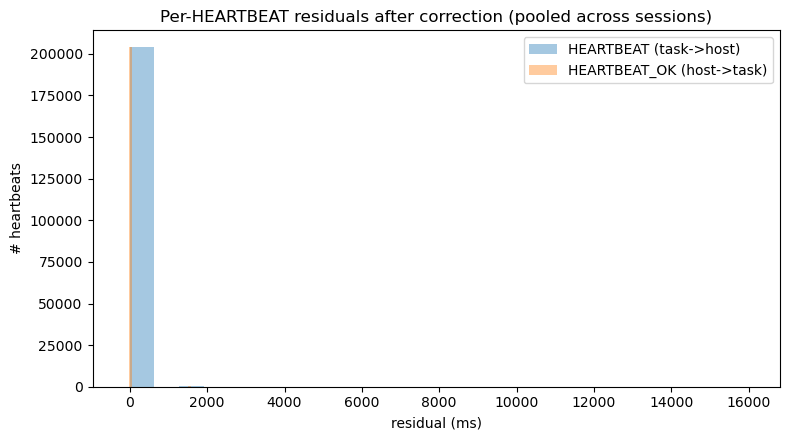


Failed sessions (6):
  subject experiment  session  original_session    stage                                                                        error  n_task_hbs  n_host_hbs
0  R1556J     RepFR1        0                 0  prepare                         task-laptop heartbeats missing - skipping correction           0        3928
1  R1564J     RepFR1        0                 0  prepare                         task-laptop heartbeats missing - skipping correction           0        2431
2  R1564J     RepFR1        1                 1  prepare  prepare failed: ValueError: Available HEARTBEATs (0) < min_heartbeats (180)        3218        3218
3  R1564J     RepFR1        2                 2  prepare  prepare failed: ValueError: Available HEARTBEATs (0) < min_heartbeats (180)        2836        2836
4  R1625T     RepFR1        1                 1  prepare                                host heartbeats missing - skipping correction           0           0
5  R1633J     RepFR1        2 

In [4]:
# Fit RANSAC linear regression for every session that produced a merged_df.
# Sessions with merged_df=None (missing logs) are skipped - no correction
# applied for those.
corrections = list()
HEARTBEAT_residuals = list()
HEARTBEAT_OK_residuals = list()
failed_sessions = list()

heartbeats_by_sess = {key: grp for key, grp in
                      heartbeats.groupby(['subject', 'experiment', 'session', 'original_session'])} \
                     if not heartbeats.empty else {}

for sess_key, prep in prepared_by_sess.items():
    sub, exp, sess, orig_sess = sess_key
    print('-' * 96)
    print(sub, exp, 'session', sess, 'original session', orig_sess)

    merged_df = prep['merged_df']
    n_task = prep['n_task']
    n_host = prep['n_host']

    if merged_df is None:
        print(f"  SKIP: {prep['prep_err']} (task HBs={n_task}, host HBs={n_host})")
        failed_sessions.append((sub, exp, sess, orig_sess, 'prepare',
                                prep['prep_err'], n_task, n_host))
        continue

    try:
        res = fit_correction(merged_df, ignore_errors=True, verbose=True, plot=False)
    except Exception as e:
        print(f"  WARNING: fit failed: {type(e).__name__}: {e}.")
        failed_sessions.append((sub, exp, sess, orig_sess, 'fit',
                                f'{type(e).__name__}: {e}', n_task, n_host))
        continue

    res['subject'] = sub
    res['experiment'] = exp
    res['session'] = sess
    res['original_session'] = orig_sess
    corrections.append(pd.DataFrame(res, index=np.arange(len(res))))

    # Stage 2: cross-validation residuals (only meaningful when we have real
    # task heartbeats - which is always now that we no longer synthesize).
    heartbeats_sess = heartbeats_by_sess.get(sess_key)
    if heartbeats_sess is None:
        continue
    try:
        heartbeats_task = correct_event_times(heartbeats_sess.query('hardware_system == "task_laptop"'),
                                              res['offset'], res['slope'], time_col='time')
        heartbeats_task = correct_event_times(heartbeats_task,
                                              res['offset'], res['slope'], time_col='time_HEARTBEAT_OK').set_index('count')
        heartbeats_host = heartbeats_sess.query('hardware_system == "host_pc"').set_index('count')

        HEARTBEAT_residuals_sess = list(heartbeats_host.time - heartbeats_task.time)
        HEARTBEAT_OK_residuals_sess = list(heartbeats_host.time_HEARTBEAT_OK - heartbeats_task.time_HEARTBEAT_OK)
        HEARTBEAT_residuals.extend(HEARTBEAT_residuals_sess)
        HEARTBEAT_OK_residuals.extend(HEARTBEAT_OK_residuals_sess)
    except Exception as e:
        print(f"  WARNING: fit succeeded but residuals computation failed: {type(e).__name__}: {e}")
        failed_sessions.append((sub, exp, sess, orig_sess, 'residuals',
                                f'{type(e).__name__}: {e}', n_task, n_host))
        continue

plt.figure(figsize=(8, 4.5))
plt.hist(HEARTBEAT_residuals, bins=25, label='HEARTBEAT (task->host)', alpha=0.4, color='C0')
plt.hist(HEARTBEAT_OK_residuals, bins=25, label='HEARTBEAT_OK (host->task)', alpha=0.4, color='C1')
plt.legend()
plt.xlabel('residual (ms)')
plt.ylabel('# heartbeats')
plt.title('Per-HEARTBEAT residuals after correction (pooled across sessions)')
plt.tight_layout()
plt.show()

corrections = pd.concat(corrections) if corrections else pd.DataFrame()
if failed_sessions:
    print(f'\nFailed sessions ({len(failed_sessions)}):')
    failed_df = pd.DataFrame(failed_sessions,
                             columns=['subject', 'experiment', 'session', 'original_session',
                                      'stage', 'error', 'n_task_hbs', 'n_host_hbs'])
    print(failed_df.to_string())






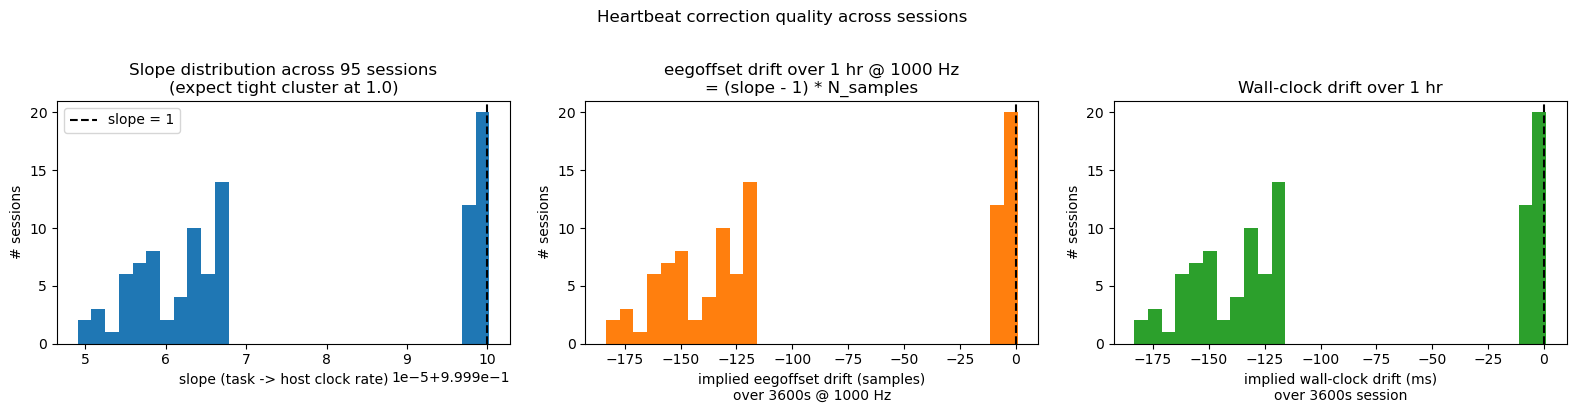

slope across 95 sessions:
  median = 0.999965175
  mean   = 0.999973696
  std    = 1.86e-05
  |slope - 1| range: [8.64e-09, 5.10e-05]
implied eegoffset drift over a 3600s session at 1000 Hz:
  median |drift| = 125.4 samples (125.4 ms)
  max    |drift| = 183.4 samples (183.4 ms)
average heartbeat roundtrip latency across sessions:
  median = 1.151 ms
  mean   = 1.155 ms


In [5]:
# ---------- Evaluate the heartbeat correction across sessions ----------
# slope distribution + implied eegoffset drift over a typical 1-hour session.

if corrections.empty:
    print('No successful corrections to evaluate.')
else:
    sess_keys = ['subject', 'experiment', 'session']
    sess_slopes = corrections.groupby(sess_keys).slope.first()
    sess_offsets = corrections.groupby(sess_keys).offset.first()
    sess_avg_lat = corrections.groupby(sess_keys).average_latency.first()

    SFREQ_REF = 1000.0
    SESS_SECONDS = 3600
    n_samples_ref = SESS_SECONDS * SFREQ_REF
    drift_samples_1hr = (sess_slopes - 1) * n_samples_ref
    drift_ms_1hr = drift_samples_1hr / SFREQ_REF * 1000

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(sess_slopes, bins=30)
    axes[0].axvline(1.0, color='k', linestyle='--', label='slope = 1')
    axes[0].set_xlabel('slope (task -> host clock rate)')
    axes[0].set_ylabel('# sessions')
    axes[0].set_title(f'Slope distribution across {len(sess_slopes)} sessions\n(expect tight cluster at 1.0)')
    axes[0].legend()

    axes[1].hist(drift_samples_1hr, bins=30, color='C1')
    axes[1].axvline(0.0, color='k', linestyle='--')
    axes[1].set_xlabel(f'implied eegoffset drift (samples)\nover {SESS_SECONDS}s @ {int(SFREQ_REF)} Hz')
    axes[1].set_ylabel('# sessions')
    axes[1].set_title('eegoffset drift over 1 hr @ 1000 Hz\n= (slope - 1) * N_samples')

    axes[2].hist(drift_ms_1hr, bins=30, color='C2')
    axes[2].axvline(0.0, color='k', linestyle='--')
    axes[2].set_xlabel(f'implied wall-clock drift (ms)\nover {SESS_SECONDS}s session')
    axes[2].set_ylabel('# sessions')
    axes[2].set_title('Wall-clock drift over 1 hr')

    fig.suptitle('Heartbeat correction quality across sessions', fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    s = sess_slopes
    d_samp = drift_samples_1hr
    d_ms = drift_ms_1hr
    print(f'slope across {len(s)} sessions:')
    print(f'  median = {s.median():.9f}')
    print(f'  mean   = {s.mean():.9f}')
    print(f'  std    = {s.std():.2e}')
    print(f'  |slope - 1| range: [{(s - 1).abs().min():.2e}, {(s - 1).abs().max():.2e}]')
    print(f'implied eegoffset drift over a {SESS_SECONDS}s session at {int(SFREQ_REF)} Hz:')
    print(f'  median |drift| = {d_samp.abs().median():.1f} samples ({d_ms.abs().median():.1f} ms)')
    print(f'  max    |drift| = {d_samp.abs().max():.1f} samples ({d_ms.abs().max():.1f} ms)')
    lat = sess_avg_lat.dropna()
    if len(lat):
        print(f'average heartbeat roundtrip latency across sessions:')
        print(f'  median = {lat.median():.3f} ms')
        print(f'  mean   = {lat.mean():.3f} ms')






In [6]:
# RANSAC inlier/outlier viz for the heartbeat fit.
# For each successful real-mode session, refits time_host = slope*time_task
# + offset using sklearn RANSAC with a 3 ms inlier threshold. Then plots:
#   LEFT  : time_task (s, rel) vs time_host (s, rel) with fit line.
#           inliers blue, outliers red.
#   RIGHT : residuals (ms) vs time, with +/- 3 ms threshold band.
#
# Limited to TOP_VIZ_SESSIONS sessions (default 3) to keep the output
# digestible. The session correction code in fix_heartbeats_sys4.py
# itself still uses plain LinearRegression - this cell is diagnostic only.

from sklearn.linear_model import RANSACRegressor, LinearRegression as _LR_VIZ

RANSAC_INLIER_MS_HB = 3.0  # |residual| <= this counts as inlier
TOP_VIZ_SESSIONS    = 3    # number of sessions to plot

if corrections.empty:
    print('No corrections to visualize.')
else:
    real_corrections = corrections[corrections['hardware_system_task'] == 'task_laptop'] \
        if 'hardware_system_task' in corrections.columns else corrections
    sess_keys = real_corrections.groupby(['subject', 'experiment', 'session']).first().head(TOP_VIZ_SESSIONS).reset_index()

    for _, row in sess_keys.iterrows():
        sub  = row['subject']
        exp  = row['experiment']
        sess = int(row['session'])
        orig_sess = int(row['original_session']) if 'original_session' in row and not pd.isna(row['original_session']) else sess
        hb_sess = heartbeats[(heartbeats['subject'] == sub) &
                             (heartbeats['experiment'] == exp) &
                             (heartbeats['session'] == sess)]
        merged = prepare_merged_heartbeats(hb_sess)
        if merged.empty: continue

        t = merged['time_task'].astype(float).values
        h = merged['time_host'].astype(float).values
        ransac = RANSACRegressor(estimator=_LR_VIZ(),
                                 residual_threshold=RANSAC_INLIER_MS_HB,
                                 random_state=0)
        ransac.fit(t.reshape(-1, 1), h)
        slope  = float(ransac.estimator_.coef_[0])
        offset = float(ransac.estimator_.intercept_)
        inlier_mask = ransac.inlier_mask_
        residuals = h - (slope * t + offset)

        t0, h0 = t[0], h[0]
        t_rel = (t - t0) / 1000.0
        h_rel = (h - h0) / 1000.0

        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

        ax = axes[0]
        ax.scatter(t_rel[inlier_mask],  h_rel[inlier_mask],
                   c='C0', s=8, alpha=0.5, label=f'inlier  (n={inlier_mask.sum()})')
        ax.scatter(t_rel[~inlier_mask], h_rel[~inlier_mask],
                   c='C3', s=14, alpha=0.7, label=f'outlier (n={(~inlier_mask).sum()})')
        t_fit_abs = np.array([t.min(), t.max()])
        h_fit_abs = slope * t_fit_abs + offset
        ax.plot((t_fit_abs - t0) / 1000.0, (h_fit_abs - h0) / 1000.0,
                'k-', lw=0.8, label='RANSAC fit')
        ax.set_xlabel('time_task - first (s)')
        ax.set_ylabel('time_host - first (s)')
        ax.set_title(f'HEARTBEAT pairs + RANSAC fit\nslope = {slope:.9f}')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

        ax = axes[1]
        ax.scatter(t_rel[inlier_mask],  residuals[inlier_mask],
                   c='C0', s=8, alpha=0.5, label='inlier')
        ax.scatter(t_rel[~inlier_mask], residuals[~inlier_mask],
                   c='C3', s=14, alpha=0.7, label='outlier')
        ax.axhline( RANSAC_INLIER_MS_HB, color='k', linestyle='--', linewidth=0.5)
        ax.axhline(-RANSAC_INLIER_MS_HB, color='k', linestyle='--', linewidth=0.5)
        ax.axhline(0, color='k', linestyle=':', linewidth=0.5)
        ax.set_xlabel('time_task - first (s)')
        ax.set_ylabel('residual (ms)')
        ax.set_title(f'Per-HEARTBEAT residuals    inlier_frac={inlier_mask.mean():.1%}    '
                     f'RMS={float(np.sqrt((residuals[inlier_mask] ** 2).mean())):.2f} ms')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)

        fig.suptitle(f'RANSAC heartbeat fit: {sub} / {exp} / ses-{sess}', fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()






ValueError: Heartbeat dataframe contains 0 != 1 sessions!

Example: subject_alias=R1204T  bids_subject=R1204T  / RepFR1 / ses-0
  slope  = 0.999962312  (|slope - 1| = 3.77e-05)
  offset = 61534488.207 ms


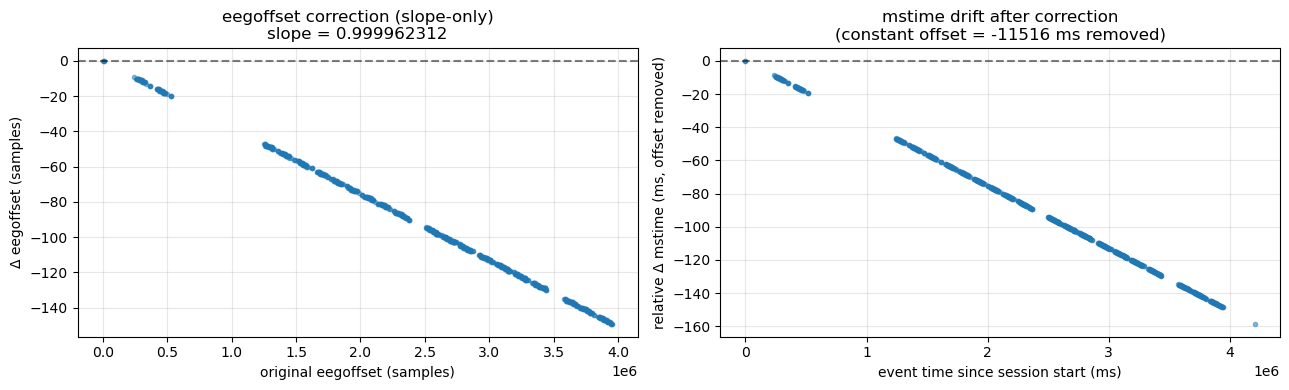


Per-event correction summary for R1204T / RepFR1 / ses-0:
  Δ eegoffset:  min = -149, max = 0, max |Δ| = 149 samples
  Δ mstime constant (heartbeat offset) = -11516.340 ms
  Δ mstime slope-induced drift over session: min = -158.406, max = 0.000, max |Δ| = 158.406 ms


In [ ]:
# ---------- Demonstrate correction on one example session ----------
# Loads events for the first session that successfully fit, applies the
# heartbeat correction (full to mstime, slope-only to eegoffset), and
# plots delta_eegoffset and delta_mstime so you can eyeball the fix.

if corrections.empty:
    print('No successful corrections to demonstrate.')
else:
    example = corrections.iloc[0]
    sub_alias = example.subject
    exp_e = example.experiment
    sess_e = int(example.session)
    slope_e = float(example.slope)
    offset_e = float(example.offset)

    matches = data.query("subject_alias == @sub_alias and experiment == @exp_e and session == @sess_e")
    if matches.empty:
        matches = data.query("subject == @sub_alias and experiment == @exp_e and session == @sess_e")
    if matches.empty:
        print(f'No data_index row found for {sub_alias} / {exp_e} / ses-{sess_e}.')
    else:
        row = matches.iloc[0]
        sub_bids = row.subject
        print(f'Example: subject_alias={sub_alias}  bids_subject={sub_bids}  / {exp_e} / ses-{sess_e}')
        print(f'  slope  = {slope_e:.9f}  (|slope - 1| = {abs(slope_e - 1):.2e})')
        print(f'  offset = {offset_e:.3f} ms')

        r_ex = CMLReader(subject=sub_bids, experiment=exp_e, session=sess_e,
                         localization=row.localization, montage=row.montage)
        events_orig = r_ex.load('events')

        eegoffset_dtype = events_orig['eegoffset'].dtype
        events_corrected = correct_event_times(events_orig, offset_e, slope_e, time_col='mstime')
        events_corrected = correct_event_times(events_corrected, 0, slope_e, time_col='eegoffset')
        events_corrected['eegoffset'] = events_corrected['eegoffset'].round().astype(eegoffset_dtype)

        delta_eegoffset = events_corrected.eegoffset.astype(float) - events_orig.eegoffset.astype(float)
        delta_mstime = events_corrected.mstime.astype(float) - events_orig.mstime.astype(float)
        rel_delta_mstime = delta_mstime - delta_mstime.iloc[0]

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        axes[0].plot(events_orig.eegoffset.values, delta_eegoffset.values, '.', alpha=0.5)
        axes[0].axhline(0, color='k', linestyle='--', alpha=0.5)
        axes[0].set_xlabel('original eegoffset (samples)')
        axes[0].set_ylabel('delta eegoffset (samples)')
        axes[0].set_title(f'eegoffset correction (slope only)\nslope = {slope_e:.9f}')
        axes[0].grid(alpha=0.3)

        axes[1].plot(events_orig.mstime.values - events_orig.mstime.iloc[0],
                     rel_delta_mstime.values, '.', alpha=0.5)
        axes[1].axhline(0, color='k', linestyle='--', alpha=0.5)
        axes[1].set_xlabel('event time since session start (ms)')
        axes[1].set_ylabel('relative delta mstime (ms, offset removed)')
        axes[1].set_title(f'mstime drift after correction\n(constant offset {delta_mstime.iloc[0]:.0f} ms removed)')
        axes[1].grid(alpha=0.3)

        fig.suptitle(f'Correction applied to events: {sub_alias} / {exp_e} / ses-{sess_e}', fontsize=12, y=1.02)
        plt.tight_layout()
        plt.show()






In [ ]:
len(heartbeats)

464977

In [ ]:
len(heartbeats.query('hardware_system == "task_laptop"'))

224246

In [ ]:
len(HEARTBEAT_residuals_sess)

2305

In [ ]:
len(HEARTBEAT_residuals)

204491

Proportion of HERTBEAT_OK delays > 50 ms: 0.9982%


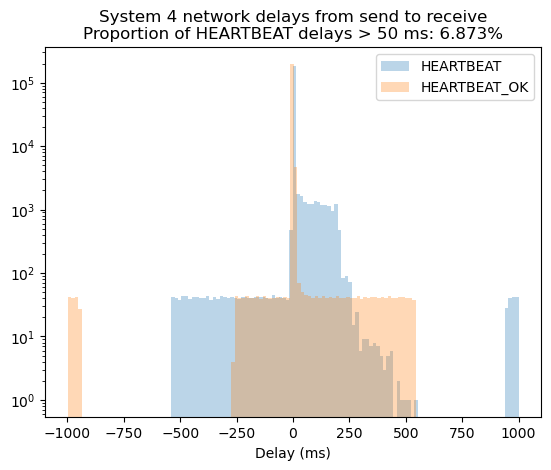

In [ ]:
# plot network delays after excluding outliers

# exclude outliers
# mask = np.ones_like(HEARTBEAT_residuals).astype(bool)
mask = np.logical_and(np.abs(HEARTBEAT_residuals) < 1e3, np.abs(HEARTBEAT_OK_residuals) < 1e3)
plt.hist(np.array(HEARTBEAT_residuals)[mask], bins=100, label='HEARTBEAT', alpha=0.3)
plt.hist(-np.array(HEARTBEAT_OK_residuals)[mask], bins=100, label='HEARTBEAT_OK', alpha=0.3)
plt.yscale('log')
plt.legend()
plt.xlabel('Delay (ms)')
long_delay = 50  # ms
prop_long_delay = (np.abs(np.array(HEARTBEAT_residuals)[mask]) > long_delay).mean()
prop_long_delay_host = (np.abs(np.array(HEARTBEAT_OK_residuals)[mask]) > long_delay).mean()
_ = plt.title(f'System 4 network delays from send to receive\nProportion of HEARTBEAT delays > {long_delay} ms: {prop_long_delay * 100:0.4}%')
print(f'Proportion of HERTBEAT_OK delays > {long_delay} ms: {prop_long_delay_host * 100:0.4}%')


Event timing questions:

How are the following event columns derived in event_creation?
- eegoffset:
    - system 4: 
    - system 3: 
    - system 2: 
- mstime:
    - system 4: 
    - system 3: 
    - system 2: 

Can the existing event parsers be used for parsing the session.json/l (with minor adjustments)?

In [ ]:
# check absolute HEARTBEAT event times
i = 15
mstime = heartbeats.time.iloc[i + 1]  # Example milliseconds timestamp
converted_datetime = ms_to_datetime(mstime)
print(f'Time of heartbeat {i + 1}:', converted_datetime)

converted_datetime1 = ms_to_datetime(heartbeats.time.iloc[i + 1])
converted_datetime2 = ms_to_datetime(heartbeats.time.iloc[i + 2])
print('Time to next heartbeat (s):', converted_datetime2 - converted_datetime1)


Time of heartbeat 16: 2021-09-30 17:32:07.490460
Time to next heartbeat (s): 0:00:01.000050


In [ ]:
# confirm that HEARTBEATs are all separated by ~1 second
check_heartbeat_onsets(heartbeats.query('hardware_system == "task_laptop"'))


Text(0.5, 0, 'Latency (ms)')

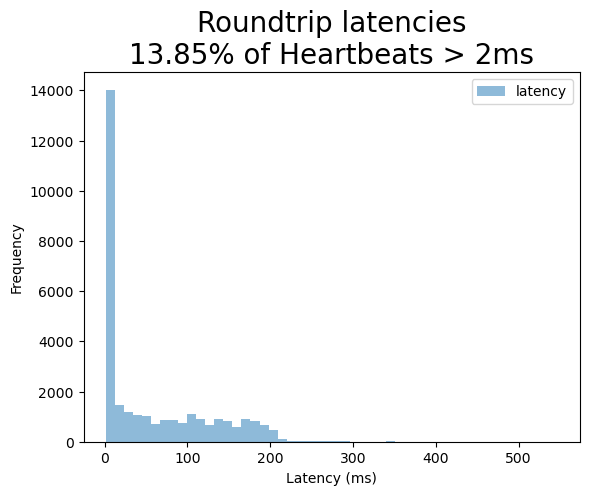

In [ ]:
# plot heartbeat roundtrip latencies
bpm_err = heartbeats.query('hardware_system == "task_laptop"').copy().latency
# threshold for marking heartbeat trips as "high latency"
threshold = 2  # ms
norm = bpm_err[bpm_err < threshold].count()
bpm_err = bpm_err[bpm_err > threshold]
bpm_err = bpm_err[bpm_err < 1000]  # exclude extreme outliers (some latencies > 1e6)
no_norm = bpm_err[bpm_err > threshold].count()
percent = no_norm/(norm+no_norm) * 100
percent = round(percent, 2)

_max = int(round(bpm_err.max()))

# *** Sets up the axes for all of the plots
# set_axes(figsize = (7, 5), fontsize = 18)
bins = 50 #np.arange(0, _max+2, step = 1)
# *** Plots the latencies *** #
bpm_err.plot.hist(bins = bins, alpha = 0.5)
plt.legend()
plt.title(f'Roundtrip latencies\n{str(percent)}% of Heartbeats > {threshold}ms', fontsize=20)
plt.xlabel('Latency (ms)')
